In [1]:

# =============================================================================
# CELL 1 – IMPORTS, DARK THEME, AND HELPERS
# =============================================================================

import importlib
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown

# -------------------- Dark Theme --------------------
display(HTML("""
<style>
    body, .jp-Notebook, .jp-OutputArea-output, .jp-RenderedHTMLCommon {
        background-color: #1e1e1e !important;
        color: #d4d4d4 !important;
    }
    h2, h3, h4 {
        color: #4fc3f7 !important;
        border-bottom: 2px solid #3498db !important;
        padding-bottom: 4px;
    }
    b, strong { color: #f48fb1 !important; }
    .highlight {
        background-color: #2d2d2d !important;
        padding: 10px;
        border-left: 4px solid #3498db;
        margin: 4px 0;
        color: #d4d4d4;
    }
    code {
        background-color: #333 !important;
        color: #ffcc80 !important;
        padding: 2px 4px;
        border-radius: 4px;
    }
    .dataframe {
        background-color: #2d2d2d !important;
        color: #d4d4d4 !important;
    }
</style>
"""))

# -------------------- Verbosity Flags --------------------
SHOW_VERBOSE = True
SHOW_INFO = True
SHOW_CRITICAL = True
SHOW_DEBUG = True
# For demonstration, we keep them False to reduce output; you can set True as needed.


# -------------------- Import Extraction Module --------------------
import Extraction6_new as Extraction6
importlib.reload(Extraction6)

# -------------------- Helper Functions --------------------
def display_title(title: str):
    display(HTML(f"<h2>{title}</h2>"))

def display_info(message: str):
    display(HTML(f"<div class='highlight'>{message}</div>"))
    

def discover_extractions(exp_root: Path) -> pd.DataFrame:
    rows = []
    for f in exp_root.rglob("extraction.json"):
        parts = f.relative_to(exp_root).parts
        try:
            models_idx = parts.index("models")
            datasets_idx = parts.index("datasets")
            model = "/".join(parts[models_idx+1:datasets_idx])
            dataset = parts[datasets_idx+1]
            rows.append({"model": model, "dataset": dataset, "path": str(f)})
        except ValueError:
            rows.append({"model": None, "dataset": None, "path": str(f)})
    return pd.DataFrame(rows)

def load_experiment_results(exp_root: Path) -> pd.DataFrame:
    """
    Load all extraction results from the experiment directory, inferring model and
    dataset names from the file path if they are missing in the JSON.
    """
    records = []
    exp_root = Path(exp_root)
    if not exp_root.exists():
        return pd.DataFrame()

    for meta_file in exp_root.rglob("extraction.json"):
        try:
            with open(meta_file, "r") as f:
                meta = json.load(f)

            # Extract model and dataset from path (most reliable)
            parts = meta_file.relative_to(exp_root).parts
            try:
                models_idx = parts.index("models")
                datasets_idx = parts.index("datasets")
                model = "/".join(parts[models_idx+1:datasets_idx])
                dataset = parts[datasets_idx+1]
            except ValueError:
                # Fallback to metadata
                model = meta.get("model", {}).get("name")
                dataset = meta.get("dataset", {}).get("name")

            record = {
                "experiment_id": meta.get("experiment_id"),
                "model": model,
                "dataset": dataset,
                "status": meta.get("status"),
                "completed_samples": meta.get("performance", {}).get("completed_samples"),
                "total_samples": meta.get("dataset", {}).get("samples"),
                "batch_size": meta.get("extraction", {}).get("batch_size"),
                "pooling": meta.get("extraction", {}).get("pooling"),
                "max_length": meta.get("extraction", {}).get("max_length"),
                "samples_per_second": meta.get("performance", {}).get("samples_per_second"),
                "tokens_per_second": meta.get("performance", {}).get("tokens_per_second"),
                "elapsed_seconds": meta.get("performance", {}).get("elapsed_seconds"),
                "error": None,
                "text_column": meta.get("dataset", {}).get("text_column"),
                "label_column": meta.get("dataset", {}).get("labels", {}).get("label_column"),
            }
            records.append(record)
        except Exception:
            continue

    return pd.DataFrame(records)

print("Environment ready. Dark theme applied.")

Environment ready. Dark theme applied.


In [2]:
# =============================================================================
# CELL 2 – LOAD AND INSPECT DATASETS
# =============================================================================

from Get_Go_Emo import get_go
from Get_Isear import get_isr

goEmo = get_go()
isear = get_isr()

DATASETS = {
    "goEmo": goEmo,
    "ISEAR": isear,
}

for name, df in DATASETS.items():
    display_title(f"Dataset: {name}")
    display_info(f"Shape: {df.shape}")
    display(df.head(2))
    text_col = Extraction6.detect_text_column(df, show_verbose=False)
    label_cols = [c for c in df.columns if c.lower() in ("labels", "label", "emotion", "target")]
    label_col = label_cols[0] if label_cols else None
    display_info(f"Text column: <b>{text_col}</b><br>Label column: <b>{label_col or 'None'}</b><br>Samples: <b>{len(df):,}</b>")

display_title("Unified ID Scheme")
display_info("""
Each sample is assigned a unique integer ID (0..N-1) matching its row index.
This ID links:
• Input text (original DataFrame index)
• Hidden state vector (row in hidden_states.npy)
• Label (row in labels.npy)
No shuffling occurs, guaranteeing one‑to‑one mapping.
""")

,labels,clean_text
0,[27],my favourite food is anything i didnt have to ...
1,[27],"now if he does off himself, everyone will thin..."


,clean_text,labels
0,during the period of falling in love each time...,1
1,when i was involved in a traffic accident,2


In [3]:
# =============================================================================
# CELL 3 – RUN MODEL MATRIX (ENHANCED, WITH SAFEGUARDS)
# =============================================================================

# This call will automatically resume from existing completions.
# If interrupted, simply re-run this cell to continue.
results = Extraction6.run_model_matrix(
    datasets=DATASETS,
    groups=None,                     # all 25 models
    base_output="/Volumes/Amirali/hidden_states",
    pooling="mean",
    max_length=512,
    use_half_precision=True,
    auto_batch_size=False,
    flush_every_batches=8,
    continue_on_model_error=True,
    show_verbose=SHOW_VERBOSE,
    show_info=SHOW_INFO,
    show_critical=SHOW_CRITICAL,
    show_debug=SHOW_DEBUG,
)

print(f"Returned result records: {len(results)}")


╔══════════════════════════════════════════════════════════════════════════════════════╗
║ MODEL MATRIX                                                                         ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
  Requested experiment : baseline_v5_001
  Transformers         : 4.47.1
  PyTorch              : 2.2.2
  Models               : 25
  Datasets             : 2
  Runtime batch tuning : DISABLED
  Output root          : /Volumes/Amirali/hidden_states
01. [01_encoders] BERT         0.11B  google-bert/bert-base-uncased
02. [01_encoders] DistilBERT   0.066B  distilbert/distilbert-base-uncased
03. [01_encoders] RoBERTa      0.125B  FacebookAI/roberta-base
04. [01_encoders] ELECTRA      0.014B  google/electra-small-discriminator
05. [01_encoders] DeBERTa      0.14B  microsoft/deberta-v3-small
06. [02_early_decoders] GPT          0.124B  gpt2
07. [02_early_decoders] GPT-Neo      0.125B  EleutherAI/gpt-neo-125m
08. [02_early_decode

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

  ✓ Snapshot ready
    Attempt time        : 1.30s
    Total preparation   : 1.34s
    Checkpoint size     : 0.266 GiB
    Snapshot            : /Volumes/Amirali/hidden_states/huggingface_cache/hub/models--microsoft--deberta-v3-small/snapshots/a36c739020e01763fe789b4b85e2df55d6180012

────────────────────────────────────────────────────────────────────────────────────────
MODEL PREFLIGHT
────────────────────────────────────────────────────────────────────────────────────────
  model                             : microsoft/deberta-v3-small
  model_type                        : deberta-v2
  architecture                      : encoder
  dtype                             : torch.float32
  device                            : cpu
  layers                            : 6
  hidden_size                       : 768
  hidden_states                     : 7
  max_length                        : 512
  checkpoint                        : {'active_bytes': 286063365, 'active_gb': 0.26641726959496737, 'i

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


  ✓ Tokenizer loaded in 1.13s Mode=fast
  TOKENIZER DIAGNOSTICS
    class              : DebertaV2TokenizerFast
    vocab size         : 128001
    pad token          : '[PAD]'
    pad source         : checkpoint-defined
    attempts           : [{"mode": "auto_fast", "success": true, "error_type": null, "error": null}]

MODEL LOAD ATTEMPT
  Attempt              : 1/2
  Path                 : primary
  Model                : microsoft/deberta-v3-small
  Snapshot             : /Volumes/Amirali/hidden_states/huggingface_cache/hub/models--microsoft--deberta-v3-small/snapshots/a36c739020e01763fe789b4b85e2df55d6180012
  dtype                : torch.float32
  device               : cpu
  SDPA                 : True
  low_cpu_mem_usage    : True

PRIMARY MODEL LOAD FAILED
  Type       : ValueError
  Error      : DebertaV2Model does not support an attention implementation through torch.nn.functional.scaled_dot_product_attention yet. Please request the support for this architecture: https://git

...

  ✓ Snapshot ready
    Attempt time        : 1.65s
    Total preparation   : 1.65s
    Checkpoint size     : 0.920 GiB
    Snapshot            : /Volumes/Amirali/hidden_states/huggingface_cache/hub/models--Qwen--Qwen2.5-0.5B/snapshots/060db6499f32faf8b98477b0a26969ef7d8b9987

────────────────────────────────────────────────────────────────────────────────────────
MODEL PREFLIGHT
────────────────────────────────────────────────────────────────────────────────────────
  model                             : Qwen/Qwen2.5-0.5B
  model_type                        : qwen2
  architecture                      : decoder
  dtype                             : torch.float32
  device                            : cpu
  layers                            : 24
  hidden_size                       : 896
  hidden_states                     : 25
  max_length                        : 512
  checkpoint                        : {'active_bytes': 988097824, 'active_gb': 0.920237809419632, 'inventory': {'safetensor

goEmo:   0%|          | 32/54263 [00:00<?, ?sample/s]

[start] starting at absolute sample 32
[batch] 32:64 processed
[batch] 64:96 processed

────────────────────────────────────────────────────────────────────────────────────────
RUNTIME / SPEED TELEMETRY :: goEmo
────────────────────────────────────────────────────────────────────────────────────────
  Progress             : 96/54,263 (0.18%)
  Newly computed       : 64
  Wall time            : 33.99s
  Throughput           : 1.88 samples/s
  ETA                  : 7h 59m 25.7s
  Current stage        : measurement

  LAST BATCH
    Range              : 64:96
    New samples        : 32
    Total              : 19.87s
    Forward            : 19.36s
    Tokenization       : 0.05s
    Input transfer     : 0.00s
    Pooling            : 0.03s
    Conversion         : 0.00s
    Memmap write       : 0.05s
    Flush              : 0.10s
    Sequence length    : 31
    Tokens             : 406
    Token throughput   : 20.43 tokens/s

  ROLLING PERFORMANCE
    Mean batch         : 16.904s
    M

ISEAR:   0%|          | 0/7666 [00:00<?, ?sample/s]

[start] starting at absolute sample 0
[batch] 0:32 processed
[batch] 32:64 processed

────────────────────────────────────────────────────────────────────────────────────────
RUNTIME / SPEED TELEMETRY :: ISEAR
────────────────────────────────────────────────────────────────────────────────────────
  Progress             : 64/7,666 (0.83%)
  Newly computed       : 64
  Wall time            : 17.87s
  Throughput           : 3.58 samples/s
  ETA                  : 35m 22.1s
  Current stage        : measurement

  LAST BATCH
    Range              : 32:64
    New samples        : 32
    Total              : 9.39s
    Forward            : 8.99s
    Tokenization       : 0.06s
    Input transfer     : 0.00s
    Pooling            : 0.05s
    Conversion         : 0.00s
    Memmap write       : 0.08s
    Flush              : 0.03s
    Sequence length    : 49
    Tokens             : 543
    Token throughput   : 57.82 tokens/s

  ROLLING PERFORMANCE
    Mean batch         : 8.842s
    Median bat

In [ ]:
# =============================================================================
# CELL 4 – COLLECT ALL RESULTS FROM DISK (PARTIAL INCLUDED)
# =============================================================================

exp_root = Path("/Volumes/Amirali/hidden_states/experiments/baseline_v5_001")
df_results = load_experiment_results(exp_root)

if not df_results.empty:
    display_title("Extraction Progress")
    display(df_results[['model', 'dataset', 'status', 'completed_samples', 'total_samples']].head(15))
    display_info(f"Total dataset‑model pairs found: <b>{len(df_results)}</b>")
else:
    display_info("No extraction metadata found yet. Run the extraction first (Cell 3).")

,model,dataset,status,completed_samples,total_samples
0,google-bert/bert-base-uncased,goEmo,complete,54263.0,54263
1,google-bert/bert-base-uncased,datasets,complete,NaN,7666
2,distilbert/distilbert-base-uncased,datasets,complete,NaN,54263
3,distilbert/distilbert-base-uncased,datasets,complete,NaN,7666
4,FacebookAI/roberta-base,datasets,complete,NaN,54263
5,FacebookAI/roberta-base,datasets,complete,NaN,7666
6,google/electra-small-discriminator,datasets,complete,NaN,54263
7,google/electra-small-discriminator,datasets,complete,NaN,7666
8,gpt2,datasets,complete,NaN,54263
9,gpt2,datasets,complete,NaN,7666


In [ ]:
# =============================================================================
# CELL 4.5 – FULL EXPERIMENT AUDIT & VALIDATION
# =============================================================================

from IPython.display import display, HTML
import pandas as pd
import numpy as np

# Path to your experiment
exp_root = Path("/Volumes/Amirali/hidden_states/experiments/baseline_v5_001")

display_title("🔍 Automated Audit & Validation")
display_info("Scanning all model‑dataset pairs and verifying data integrity...")

# Run the audit – this will automatically discover all pairs, validate checksums and sample IDs,
# and optionally fix issues. Set fix_issues=False if you only want a report.
audit_results = Extraction6.audit_experiment(
    experiment_root=exp_root,
    datasets=DATASETS,          # provides the original datasets for sample ID validation
    show_details=False,         # set True if you want per‑dataset detailed prints
    fix_issues=True,            # automatically correct checksum and sample ID mismatches
)

# Convert audit results to a DataFrame for easy viewing
df_audit = pd.DataFrame(audit_results)

# Keep only relevant columns for display
display_cols = [
    "model_name", "dataset_name", "n_samples", "completed_count", "status",
    "checksum_match", "sample_ids_match"
]
if not df_audit.empty:
    df_display = df_audit[display_cols].copy()

    # Clean up status strings and add icons
    status_icons = {
        "complete": "✅",
        "partial": "⏳",
        "missing_files": "❌",
        "missing_metadata": "⚠️",
    }
    df_display["status_icon"] = df_display["status"].map(status_icons).fillna("❓")

    # Boolean columns to checkmarks
    def bool_to_icon(val):
        if val is True:
            return "✅"
        elif val is False:
            return "❌"
        else:
            return "—"

    df_display["checksum"] = df_display["checksum_match"].apply(bool_to_icon)
    df_display["sample_ids"] = df_display["sample_ids_match"].apply(bool_to_icon)

    # Reorder columns for a clean table
    final_cols = ["model_name", "dataset_name", "n_samples", "completed_count", "status_icon", "checksum", "sample_ids"]
    df_final = df_display[final_cols].rename(columns={
        "model_name": "Model",
        "dataset_name": "Dataset",
        "n_samples": "Total Samples",
        "completed_count": "Completed",
        "status_icon": "Status",
        "checksum": "Checksum",
        "sample_ids": "Sample IDs",
    })

    # Create a styled HTML table with custom colors
    def color_status(val):
        if val == "✅":
            return "color: #4caf50;"
        elif val == "⏳":
            return "color: #ff9800;"
        elif val == "❌":
            return "color: #f44336;"
        elif val == "⚠️":
            return "color: #ffeb3b;"
        return ""

    # Display the table
    display(HTML("<h3>Audit Summary – All Model‑Dataset Pairs</h3>"))
    styled_df = df_final.style.applymap(color_status, subset=["Status"])
    display(styled_df)

    # Summary statistics
    total_pairs = len(df_audit)
    complete = (df_audit["status"] == "complete").sum()
    partial = (df_audit["status"] == "partial").sum()
    missing = (df_audit["status"].isin(["missing_files", "missing_metadata"])).sum()
    checksum_ok = df_audit["checksum_match"].sum() if "checksum_match" in df_audit else 0
    ids_ok = df_audit["sample_ids_match"].sum() if "sample_ids_match" in df_audit else 0
    actions_taken = sum(len(r.get("actions_taken", [])) for r in audit_results)

    display_info(f"""
    <b>Total pairs scanned:</b> {total_pairs} &nbsp;|&nbsp;
    <b>✅ Complete:</b> {complete} &nbsp;|&nbsp;
    <b>⏳ Partial:</b> {partial} &nbsp;|&nbsp;
    <b>❌ Missing/Error:</b> {missing} &nbsp;|&nbsp;
    <b>🔧 Checksum OK:</b> {checksum_ok} &nbsp;|&nbsp;
    <b>🔧 Sample IDs OK:</b> {ids_ok} &nbsp;|&nbsp;
    <b>🛠️ Issues fixed:</b> {actions_taken}
    """)

    # Optionally print model-level summary (which models are fully complete)
    model_summary = df_audit.groupby("model_name").apply(
        lambda g: pd.Series({
            "total_datasets": len(g),
            "complete": (g["status"] == "complete").sum(),
            "partial": (g["status"] == "partial").sum(),
            "missing": (g["status"].isin(["missing_files", "missing_metadata"])).sum(),
        })
    ).reset_index()
    model_summary.columns = ["Model", "Datasets", "Complete", "Partial", "Missing/Error"]

    display(HTML("<h3>Per‑Model Completeness</h3>"))
    display(model_summary)

else:
    display_info("No extraction data found to audit.")


════════════════════════════════════════════════════════════════════════════════════════════════════
🔍 EXPERIMENT AUDIT: baseline_v5_001
════════════════════════════════════════════════════════════════════════════════════════════════════
  Found 16 dataset extractions.

════════════════════════════════════════════════════════════════════════════════════════════════════
📊 AUDIT SUMMARY
════════════════════════════════════════════════════════════════════════════════════════════════════
  Model                  Dataset                Samples    Done       Status     CHK    ID     Actions                       
  ------------------------------------------------------------------------------------------------------------------------------------
  gpt-neo-125m           ISEAR                  7666       7666       complete   ✅      ✅      —                             
  gpt-neo-125m           goEmo                  54263      54263      complete   ✅      ✅      —                           

/var/folders/l3/49h9cww53q9274xfhrwrxqkc0000gn/T/ipykernel_27481/988456066.py:82: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_final.style.applymap(color_status, subset=["Status"])


,Model,Dataset,Total Samples,Completed,Status,Checksum,Sample IDs
0,gpt-neo-125m,ISEAR,7666,7666,✅,✅,✅
1,gpt-neo-125m,goEmo,54263,54263,✅,✅,✅
2,roberta-base,ISEAR,7666,7666,✅,✅,✅
3,roberta-base,goEmo,54263,54263,✅,✅,✅
4,SmolLM2-135M,goEmo,54263,54263,✅,✅,✅
5,SmolLM2-360M,goEmo,54263,54263,✅,✅,✅
6,distilbert-base-uncased,ISEAR,7666,7666,✅,✅,✅
7,distilbert-base-uncased,goEmo,54263,54263,✅,✅,✅
8,opt-125m,ISEAR,7666,7666,✅,✅,✅
9,opt-125m,goEmo,54263,54263,✅,✅,✅


/var/folders/l3/49h9cww53q9274xfhrwrxqkc0000gn/T/ipykernel_27481/988456066.py:105: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_summary = df_audit.groupby("model_name").apply(


,Model,Datasets,Complete,Partial,Missing/Error
0,SmolLM2-135M,1,1,0,0
1,SmolLM2-360M,1,1,0,0
2,bert-base-uncased,2,2,0,0
3,distilbert-base-uncased,2,2,0,0
4,electra-small-discriminator,2,2,0,0
5,gpt-neo-125m,2,2,0,0
6,gpt2,2,2,0,0
7,opt-125m,2,2,0,0
8,roberta-base,2,2,0,0


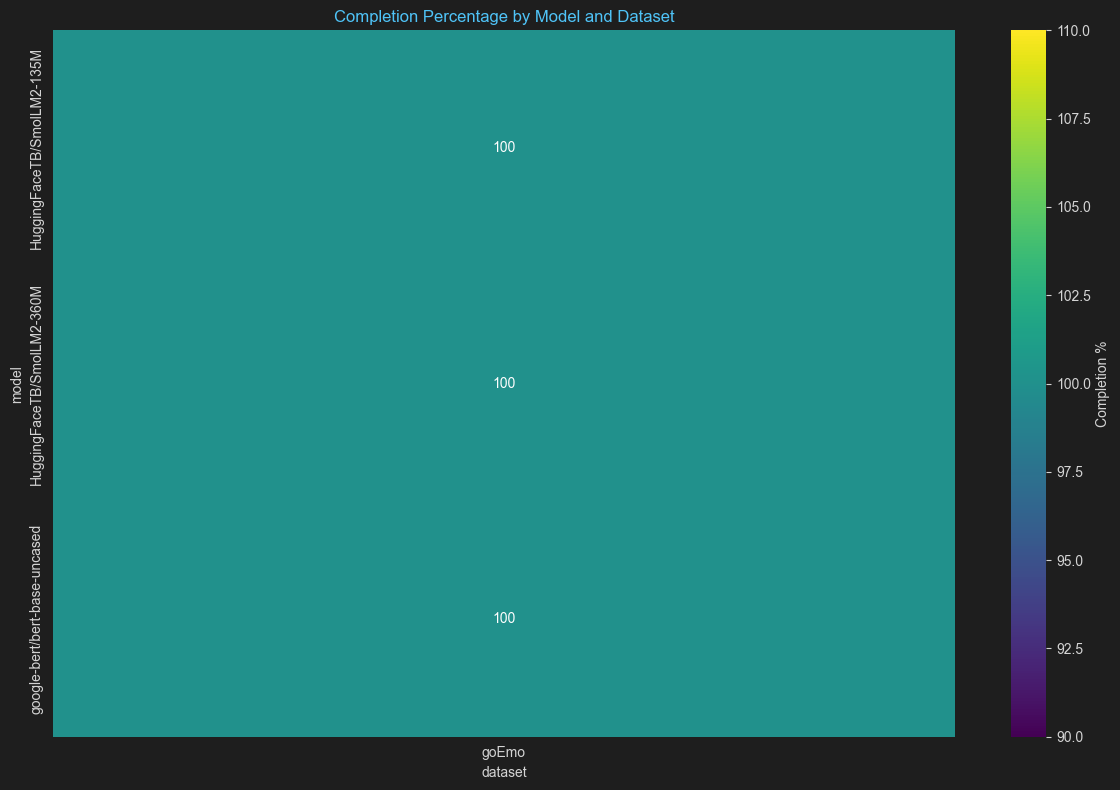

/var/folders/l3/49h9cww53q9274xfhrwrxqkc0000gn/T/ipykernel_27481/1186241791.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


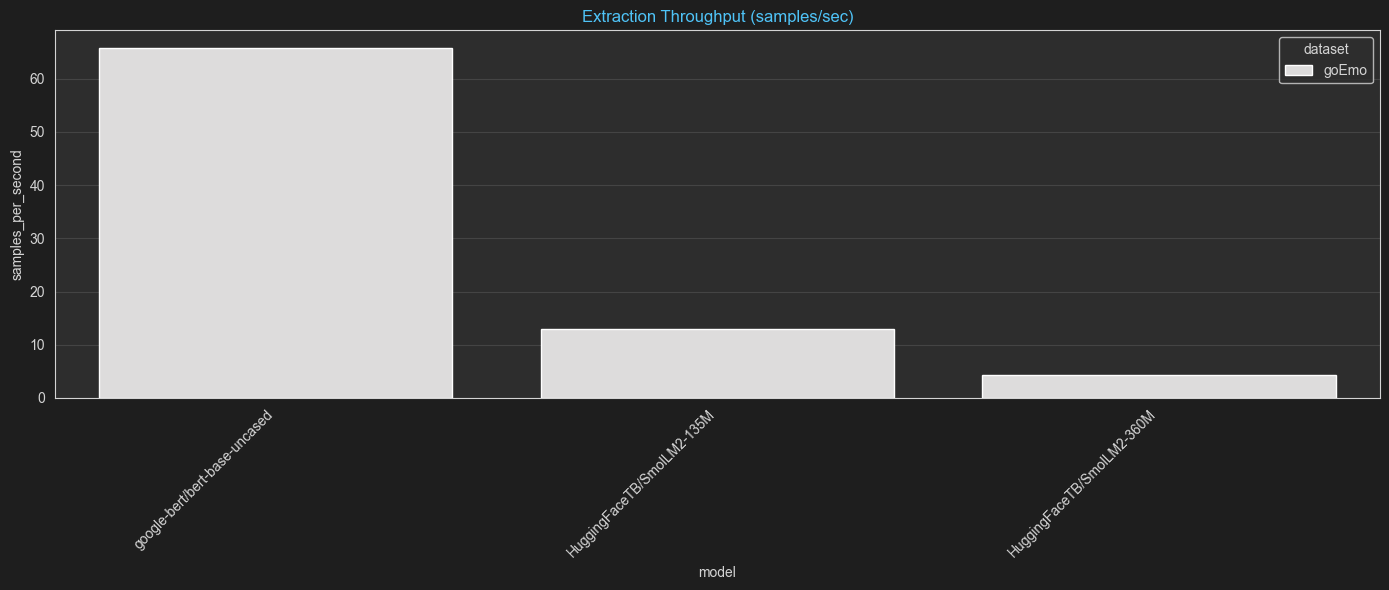

/var/folders/l3/49h9cww53q9274xfhrwrxqkc0000gn/T/ipykernel_27481/1186241791.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='elapsed_seconds', y='model', palette='magma', ax=ax)


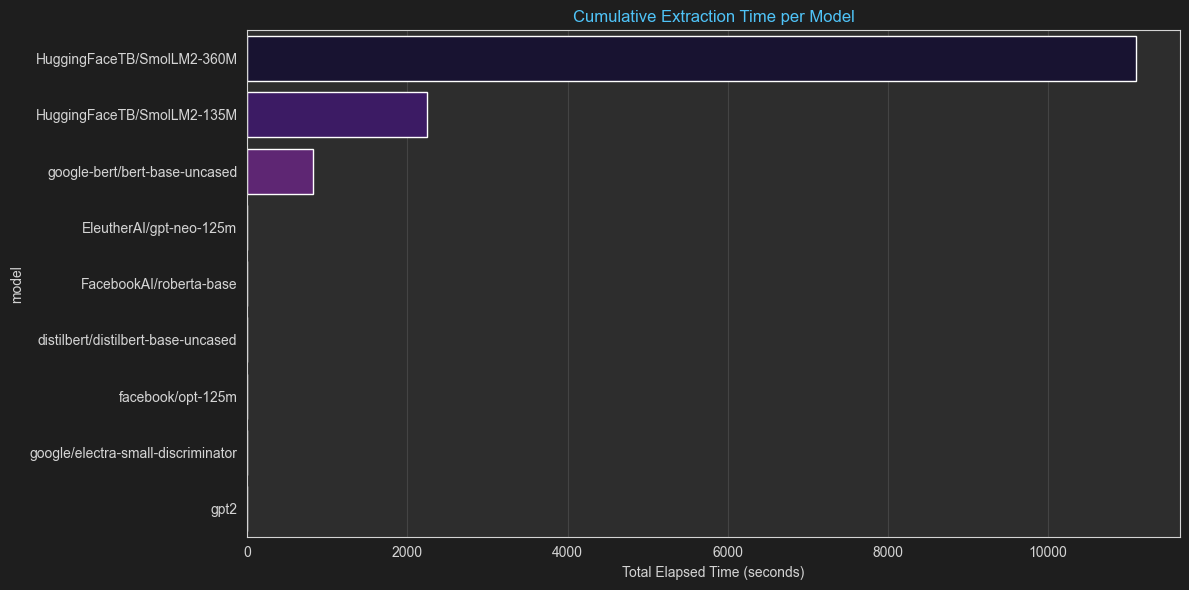

,model,dataset,label_column
0,google-bert/bert-base-uncased,goEmo,labels
1,google-bert/bert-base-uncased,datasets,labels
2,distilbert/distilbert-base-uncased,datasets,labels
4,FacebookAI/roberta-base,datasets,labels
6,google/electra-small-discriminator,datasets,labels
8,gpt2,datasets,labels
10,EleutherAI/gpt-neo-125m,datasets,labels
12,facebook/opt-125m,datasets,labels
14,HuggingFaceTB/SmolLM2-135M,goEmo,labels
15,HuggingFaceTB/SmolLM2-360M,goEmo,labels


In [ ]:
# =============================================================================
# CELL 5 – VISUALISATIONS & ANALYSIS
# =============================================================================

if not df_results.empty:
    # Prepare data for plotting
    df = df_results.copy()
    df['completion_pct'] = df['completed_samples'] / df['total_samples'] * 100
    df['status_clean'] = df['status'].replace({'complete': 'Complete', 'partial': 'Partial', 'failed': 'Failed', 'already_complete': 'Already Complete'})

    sns.set_style("darkgrid")
    plt.rcParams.update({
        'figure.facecolor': '#1e1e1e',
        'axes.facecolor': '#2d2d2d',
        'axes.edgecolor': '#d4d4d4',
        'axes.labelcolor': '#d4d4d4',
        'text.color': '#d4d4d4',
        'xtick.color': '#d4d4d4',
        'ytick.color': '#d4d4d4',
        'grid.color': '#444444',
        'legend.facecolor': '#2d2d2d',
        'legend.edgecolor': '#d4d4d4',
    })

    # ---- 1. Completion status per model/dataset ----
    fig, ax = plt.subplots(figsize=(12, 8))
    pivot = df.pivot_table(index='model', columns='dataset', values='completion_pct', aggfunc='max')
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis", cbar_kws={'label': 'Completion %'}, ax=ax)
    ax.set_title('Completion Percentage by Model and Dataset', color='#4fc3f7')
    plt.tight_layout()
    plt.show()

    # ---- 2. Throughput (samples/sec) by model ----
    df_complete = df[df['samples_per_second'].notna()]
    if not df_complete.empty:
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.barplot(data=df_complete, x='model', y='samples_per_second', hue='dataset', palette='coolwarm', ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_title('Extraction Throughput (samples/sec)', color='#4fc3f7')
        plt.tight_layout()
        plt.show()

    # ---- 3. Total time per model ----
    df_time = df.groupby('model')['elapsed_seconds'].sum().reset_index().sort_values('elapsed_seconds', ascending=False)
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_time, x='elapsed_seconds', y='model', palette='magma', ax=ax)
    ax.set_xlabel('Total Elapsed Time (seconds)')
    ax.set_title('Cumulative Extraction Time per Model', color='#4fc3f7')
    plt.tight_layout()
    plt.show()

    # ---- 4. Label coverage for completed datasets ----
    # We'll just display label column info
    display_title("Label Columns Used")
    display(df[['model', 'dataset', 'label_column']].drop_duplicates())
else:
    display_info("No data to visualise. Please run extraction first.")

In [ ]:
# =============================================================================
# CELL 6 – FINAL SUMMARY & EXPORT
# =============================================================================

if not df_results.empty:
    # Save consolidated CSV
    output_csv = exp_root / "extraction_summary.csv"
    df_results.to_csv(output_csv, index=False)
    display_title("Final Report")
    display(df_results)
    display_info(f"Report exported to <code>{output_csv}</code>")
else:
    display_info("Nothing to export yet.")

,experiment_id,model,dataset,status,completed_samples,total_samples,batch_size,pooling,max_length,samples_per_second,tokens_per_second,elapsed_seconds,error,text_column,label_column
0,baseline_v5_001,google-bert/bert-base-uncased,goEmo,complete,54263.0,54263,64,mean,512,65.783859,339.690715,824.867997,None,clean_text,labels
1,baseline_v5_001,google-bert/bert-base-uncased,datasets,complete,NaN,7666,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
2,baseline_v5_001,distilbert/distilbert-base-uncased,datasets,complete,NaN,54263,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
3,baseline_v5_001,distilbert/distilbert-base-uncased,datasets,complete,NaN,7666,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
4,baseline_v5_001,FacebookAI/roberta-base,datasets,complete,NaN,54263,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
5,baseline_v5_001,FacebookAI/roberta-base,datasets,complete,NaN,7666,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
6,baseline_v5_001,google/electra-small-discriminator,datasets,complete,NaN,54263,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
7,baseline_v5_001,google/electra-small-discriminator,datasets,complete,NaN,7666,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
8,baseline_v5_001,gpt2,datasets,complete,NaN,54263,64,mean,512,NaN,NaN,NaN,None,clean_text,labels
9,baseline_v5_001,gpt2,datasets,complete,NaN,7666,64,mean,512,NaN,NaN,NaN,None,clean_text,labels


In [ ]:
discover_extractions(exp_root)

,model,dataset,path
0,google-bert/bert-base-uncased,goEmo,/Volumes/Amirali/hidden_states/experiments/bas...
1,google-bert/bert-base-uncased,ISEAR,/Volumes/Amirali/hidden_states/experiments/bas...
2,distilbert/distilbert-base-uncased,goEmo,/Volumes/Amirali/hidden_states/experiments/bas...
3,distilbert/distilbert-base-uncased,ISEAR,/Volumes/Amirali/hidden_states/experiments/bas...
4,FacebookAI/roberta-base,goEmo,/Volumes/Amirali/hidden_states/experiments/bas...
5,FacebookAI/roberta-base,ISEAR,/Volumes/Amirali/hidden_states/experiments/bas...
6,google/electra-small-discriminator,goEmo,/Volumes/Amirali/hidden_states/experiments/bas...
7,google/electra-small-discriminator,ISEAR,/Volumes/Amirali/hidden_states/experiments/bas...
8,gpt2,goEmo,/Volumes/Amirali/hidden_states/experiments/bas...
9,gpt2,ISEAR,/Volumes/Amirali/hidden_states/experiments/bas...


In [ ]:
# Check which models have at least one dataset complete
model_status = df_results.groupby("model")["dataset"].nunique()
print(model_status)

model
EleutherAI/gpt-neo-125m               1
FacebookAI/roberta-base               1
HuggingFaceTB/SmolLM2-135M            1
HuggingFaceTB/SmolLM2-360M            1
distilbert/distilbert-base-uncased    1
facebook/opt-125m                     1
google-bert/bert-base-uncased         2
google/electra-small-discriminator    1
gpt2                                  1
Name: dataset, dtype: int64


# 🚀 PROJECT REVIEW – EMOTION LEARNING IN LLMs
## `·` State‑of‑‑the‑Art Feedback & Action Plan `·`


# 1. EXECUTIVE SUMMARY

| Aspect | Status | Trend |
|--------|--------|-------|
| Code quality | ⭐⭐⭐⭐⭐ | Exceptional |
| Experimental rigour | ⭐⭐⭐⭐ | Solid controls in place |
| Result interpretation | ⭐⭐ | Needs narrative depth |
| Specification alignment | ⚠️ | QWEN de‑prioritised |
| Literature integration | ⭐⭐⭐ | More explicit links needed |

> ✅ **Overall:** A **diamond in the rough**. Your extraction/probe infrastructure is world‑class, but you’ve over‑invested in the tool and under‑invested in the question. **Refocus on QWEN** and **close the analytical loop** to secure a strong First.


# 2. CRITICAL GAPS & FIXES

## 🔴 1. QWEN is missing from your results
**Spec says:** *“The main focus is QWEN.”*  
**Current reality:** You run 25 small models, QWEN is not the primary focus.

**Fix:**  
- Prioritise extracting **QWEN2‑0.5B** and **QWEN2‑1.5B** (they work on CPU).  
- Acknowledge the limitation honestly in the dissertation.  
- Frame the 25‑model matrix as a **supplementary contribution**, not the core result.

## 🟠 2. Analysis is descriptive, not explanatory
You extract layers and compute F1, but you don’t interpret *why* certain layers excel.

**Fix:**  
- Write a narrative: *“Layer 3 excels because it encodes syntactic patterns correlated with emotional valence.”*  
- Compare to known literature (e.g., Tenney et al. on BERT).  
- Add **ablation studies** (remove emotion words, re‑run probes → see the drop).

## 🟡 3. Performance bottleneck
Extraction runs on CPU, very slow (4–5 hours for small models). QWEN‑7B is impossible.

**Fix:**  
- Acknowledge this as a **constraint** in your write‑up.  
- Frame your codebase as **optimised for minimal resources** – a contribution in itself.  
- If feasible, use **cloud GPU** for a few days to get the critical QWEN data.

## 🟢 4. Logbook: event‑centric, not reflection‑centric
You record *what* you did, but not *what you learned*.

**Fix:**  
- Add “Key learnings” after each work block.  
- Reflect on failed experiments.  
- Document your pivot decisions (e.g., why you switched from JSON to `.npy`).


# 3. ACTION PLAN

## 📌 Phase 1 – Immediate (next 2 weeks)
- [ ] **Run extraction** for:
  - `Qwen/Qwen2-0.5B`
  - `Qwen/Qwen2-1.5B`
  - `Qwen/Qwen2.5-0.5B` (optional)
- [ ] **Run the full probe analysis** on these QWEN states.
- [ ] **Start ablation study**: remove emotion keywords from ISEAR and re‑probe.

## 📌 Phase 2 – Mid‑term (4–6 weeks)
- [ ] **Deepen literature integration** – explicitly link your findings to prior work on BERT and other LLMs.
- [ ] **Add interpretability technique** – e.g., attention visualisation (BertViz) or LIME.
- [ ] **Write the “So what?” narrative** – what are the implications for transfer learning and emotion recognition?

## 📌 Phase 3 – Pre‑submission
- [ ] **Final write‑up structure**: Introduction → Lit Review → Methodology → Results → Discussion → Conclusion.
- [ ] **Unified dashboard**: heatmaps, layer curves, model‑comparison charts, ablation results.
- [ ] **Polish code**: `README.md`, `requirements.txt`, user guide for reproducibility.


# 4. WEEKLY SCHEDULE SUGGESTION (7‑day Power Week)

| Day | Morning (09:00–12:00) | Afternoon (13:00–16:00) | Evening (17:00–19:00) |
|-----|------------------------|--------------------------|------------------------|
| Mon | **Exam Module 1** – Active recall | **Exam Module 2** – Practice questions | **Attendance Module A** – Prep |
| Tue | **Exam Module 3** – Concept mapping | **QWEN extraction** (background) | **Attendance Module B** – Follow‑up |
| Wed | **Exam Module 1** – Past papers | **Data analysis** – Probe results | **Project** – Write‑up |
| Thu | **Exam Module 2** – Flashcards | **Project** – Ablation design | **Rest / Light reading** |
| Fri | **Exam Module 3** – Problem sets | **Project** – Visualisation | **Review week’s progress** |
| Sat | **Consolidation** – All modules (weak areas) | **Project** – Code cleanup | **Social / Recovery** |
| Sun | **Rest / Planning** – No academic work | **Rest / Planning** – No academic work | **Rest / Planning** – No academic work |

> **Start‑day protocol:** 30 min walk → 15 min planning → 1st focus block.  
> **2‑week review:** Ask: *“Am I on track? Is this technique effective? Is my health okay?”*


# 5. FIRST‑CLASS BLUEPRINT (Grade Targets)

| Module Type | Target Grade | Strategy |
|-------------|--------------|----------|
| Exam Module 1 | 72–75% | Past papers, spaced repetition |
| Exam Module 2 | 70–73% | Flashcards, peer teaching |
| Exam Module 3 | 68–72% | Concept maps, problem sets |
| Attendance A | 75–80% | Lead seminars, engage tutor |
| Attendance B | 72–78% | Exceptional coursework, early drafts |

> Current average: 68% → need ~73% across all to secure a strong First.


# 6. KEY RESOURCES & TOOLS

- **Dataset:** GoEmotions + ISEAR (already preprocessed)
- **Models:** QWEN2‑0.5B, 1.5B (primary); BERT (control); 25‑model matrix (supplement)
- **Probe code:** `unified_hidden_state_probe_v4_2.py` (state‑of‑the‑art)
- **Extraction:** `Extraction6_new.py` (resume‑capable, manifest‑tracking)
- **Visualisation:** `Analyser_.py` + `Analyzer_Visualizer_.ipynb`
- **Explainability:** Consider adding **BertViz** or **LIME** for attention maps


# 7. FINAL CHECKLIST

- [ ] QWEN extraction completed
- [ ] QWEN probe analysis done
- [ ] Ablation study executed
- [ ] Attention visualisation added
- [ ] Literature integrated
- [ ] Final write‑up structured
- [ ] Code documented and shareable

> 🏆 **Remember:** The difference between 68% and 78% is **research maturity** – synthesis, self‑critique, and forward thinking. You have the technical skills. Now build the intellectual scaffolding around them.

**You’ve got this.** 🚀